# Credit Card Fraud Detection System
## Explainable payment and earlier-spending features

This notebook accompanies the main CreditVault dashboard. It studies supervised detection of fraud-labeled **synthetic credit-card transactions** using payment details and account activity available strictly before that payment.

The dataset is a verified Sparkov-derived `fraudTest.csv` portion. Its source filename does not define our test set: this project creates its own chronological training, validation, and test periods. The original PCA notebook remains a separate historical experiment.

**Execution modes:** by default, these cells reproduce EDA, feature generation, the full final test evaluation of the saved model, and explanation/inference parity. They load the genuine four-model training report exported by `prepare_card_model.py`; they do not pretend to retrain it. Set `CARD_RETRAIN=1` to execute the complete training experiment as part of this notebook.

Before opening Jupyter, install `requirements-dev.txt` from the repository root. Set `CARD_DATA_CSV` to the verified source CSV outside the checkout. For a fresh training run, also set `CARD_SOURCE_MANIFEST` to its audit manifest. See `docs/CARD_MODEL.md` for provenance and preparation.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys

# Work from either the repository root or its notebooks directory.
REPO = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / "card_core.py").exists()), None)
if REPO is None:
    raise RuntimeError("Open this notebook from the project or its notebooks directory.")
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

from card_core import (BASE_FEATURES, FEATURES, RAW_COLUMNS, FEATURE_LABELS,
                       build_features, load_card_bundle, payment_features,
                       score_payment, explain_payment)
from prepare_card_model import RENAME, pipeline_for, evaluate, train

DATA_CSV = Path(os.environ.get("CARD_DATA_CSV", str(REPO.parent / "data" / "sparkov_verified.csv"))).expanduser()
ARTIFACTS = REPO / "card_artifacts"
RETRAIN = os.environ.get("CARD_RETRAIN", "0") == "1"
manifest_path = Path(os.environ["CARD_SOURCE_MANIFEST"]).expanduser() if os.environ.get("CARD_SOURCE_MANIFEST") else None
if not DATA_CSV.is_file():
    raise FileNotFoundError("Set CARD_DATA_CSV to the verified full CSV outside the checkout, then restart the kernel.")
if manifest_path and manifest_path.is_file():
    source_manifest = json.loads(manifest_path.read_text())
elif (ARTIFACTS / "metadata.json").is_file():
    source_manifest = json.loads((ARTIFACTS / "metadata.json").read_text())["source"]
else:
    raise FileNotFoundError("For a first build, set CARD_SOURCE_MANIFEST to the verified source audit JSON.")
if RETRAIN and (manifest_path is None or not manifest_path.is_file()):
    raise FileNotFoundError("CARD_RETRAIN=1 requires CARD_SOURCE_MANIFEST.")
print("Mode:", "complete training experiment" if RETRAIN else "saved-run evaluation reproduction; no retraining")
print("Data:", DATA_CSV.name)

Mode: saved-run evaluation reproduction; no retraining
Data: sparkov_verified.csv


## 1. Verify the source and select only needed fields

The SHA-256 check links this run to the audited source. Personal details are not loaded. Stable aliases replace the source's synthetic card numbers. Transaction IDs and aliases identify records and group history; neither is passed to the estimator.

In [2]:
digest = hashlib.sha256()
with DATA_CSV.open("rb") as source_file:
    for chunk in iter(lambda: source_file.read(8 * 1024 * 1024), b""):
        digest.update(chunk)
assert digest.hexdigest() == source_manifest["verified_csv_sha256"], "CSV differs from the verified source."
raw = pd.read_csv(DATA_CSV, usecols=[*RENAME, "merchant", "category"],
                  dtype={"cc_num": str}, float_precision="round_trip").rename(columns=RENAME)
assert raw.label.isin([0, 1]).all()
assert not raw.transaction_id.duplicated().any()
assert not raw.isna().any().any()
raw["timestamp"] = pd.to_datetime(raw["timestamp"], errors="raise")
assert np.isfinite(raw.amount).all() and raw.amount.gt(0).all()
aliases = {account: f"CARD-{i+1:04d}" for i, account in enumerate(sorted(raw.account_id.unique()))}
raw["account_id"] = raw.account_id.map(aliases)
audit = {
    "transactions": len(raw), "fraud": int(raw.label.sum()),
    "fraud_percent": 100 * raw.label.mean(), "accounts": raw.account_id.nunique(),
    "first_timestamp": str(raw.timestamp.min()), "last_timestamp": str(raw.timestamp.max()),
    "categories": raw.category.nunique(), "currency": "USD", "synthetic": True,
}
display(pd.Series(audit, name="Verified source"))
display(raw.head())

transactions                    555719
fraud                             2145
fraud_percent                 0.385986
accounts                           924
first_timestamp    2020-06-21 12:14:25
last_timestamp     2020-12-31 23:59:34
categories                          14
currency                           USD
synthetic                         True
Name: Verified source, dtype: object

,timestamp,account_id,merchant,category,amount,transaction_id,label
0,2020-06-21 12:14:25,CARD-0099,fraud_Kirlin and Sons,personal_care,2.86,2da90c7d74bd46a0caf3777415b3ebd3,0
1,2020-06-21 12:14:33,CARD-0338,fraud_Sporer-Keebler,personal_care,29.84,324cc204407e99f51b0d6ca0055005e7,0
2,2020-06-21 12:14:53,CARD-0382,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,c81755dbbbea9d5c77f094348a7579be,0
3,2020-06-21 12:15:15,CARD-0369,fraud_Haley Group,misc_pos,60.05,2159175b9efe66dc301f149d3d5abf8c,0
4,2020-06-21 12:15:17,CARD-0256,fraud_Johnston-Casper,travel,3.19,57ff021bd3f328f8738bb535c302a31b,0


## 2. Exploratory data analysis

Fraud is rare. Accuracy must therefore be compared with an always-legitimate baseline. Class-normalized amount/time plots compare shapes without letting the majority class hide the fraud cases. These are descriptive plots; they do not select the model from the final test period.

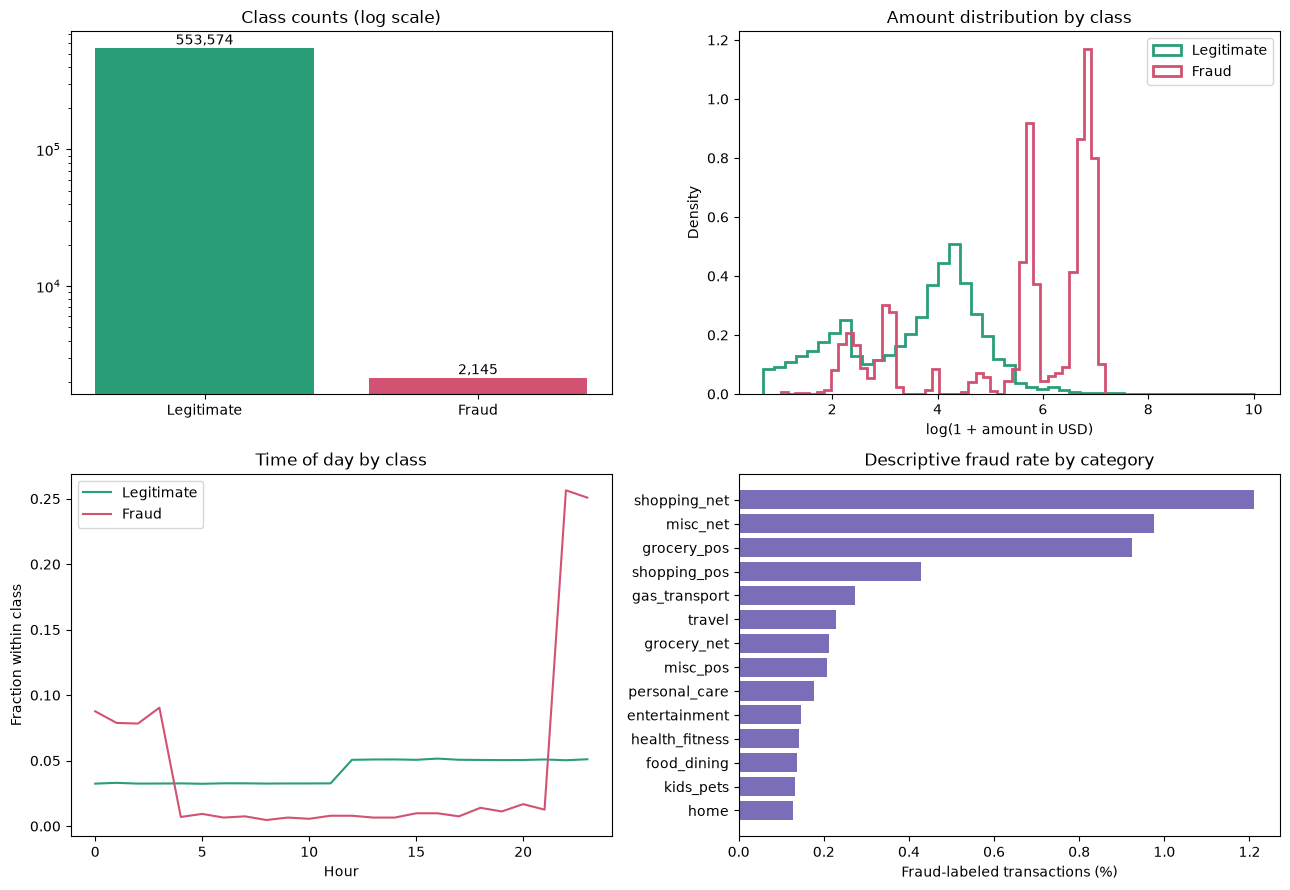

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
counts = raw.label.value_counts().reindex([0, 1])
axes[0, 0].bar(["Legitimate", "Fraud"], counts, color=["#299e79", "#d25271"])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Class counts (log scale)")
for index, value in enumerate(counts):
    axes[0, 0].text(index, value, f"{value:,}", ha="center", va="bottom")
for label, color, title in ((0, "#299e79", "Legitimate"), (1, "#d25271", "Fraud")):
    subset = raw.loc[raw.label.eq(label)]
    axes[0, 1].hist(np.log1p(subset.amount), bins=45, density=True,
                    histtype="step", linewidth=2, color=color, label=title)
    hourly = subset.timestamp.dt.hour.value_counts(normalize=True).reindex(range(24), fill_value=0)
    axes[1, 0].plot(hourly.index, hourly.values, color=color, label=title)
axes[0, 1].set_title("Amount distribution by class")
axes[0, 1].set_xlabel("log(1 + amount in USD)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()
axes[1, 0].set_title("Time of day by class")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Fraction within class")
axes[1, 0].legend()
category_rates = raw.groupby("category").label.mean().sort_values()
axes[1, 1].barh(category_rates.index, 100 * category_rates.values, color="#7b6db7")
axes[1, 1].set_title("Descriptive fraud rate by category")
axes[1, 1].set_xlabel("Fraud-labeled transactions (%)")
fig.tight_layout()
plt.show()

## 3. Calculate understandable, strictly earlier features

`build_features` uses the same code as dashboard inference. It excludes the current transaction, tied timestamps, future payments, and every fraud label from the history. An amount/history ratio is undefined for a new account; the pipeline later imputes numeric missing values using training medians and retains the history-availability indicator.

Hour sine/cosine are an ordinary clock encoding: they keep times near midnight close together. They are not anonymized PCA components.

In [4]:
data = build_features(raw)
feature_dictionary = pd.DataFrame({
    "Feature": FEATURES,
    "Meaning": [FEATURE_LABELS[name] for name in FEATURES],
    "Availability": ["Current payment" if name in BASE_FEATURES else "Strictly earlier account activity" for name in FEATURES],
})
display(feature_dictionary)
display(data[["account_id", "timestamp", "amount", "prior_count", "prior_mean_amount",
              "amount_vs_mean", "transactions_1h", "merchant_seen", "history_available"]].head(8))

# Demonstrate the timestamp-tie boundary, independent of the real fraud labels.
tiny = pd.DataFrame([
    {"account_id":"EXAMPLE", "timestamp":"2020-01-01 09:00", "amount":10,
     "merchant":"A", "category":"grocery_pos", "transaction_id":"one"},
    {"account_id":"EXAMPLE", "timestamp":"2020-01-01 10:00", "amount":20,
     "merchant":"B", "category":"shopping_net", "transaction_id":"two"},
    {"account_id":"EXAMPLE", "timestamp":"2020-01-01 10:00", "amount":30,
     "merchant":"C", "category":"shopping_net", "transaction_id":"three"},
])
tied = build_features(tiny)
assert tied.loc[tied.timestamp.eq(pd.Timestamp("2020-01-01 10:00")), "prior_mean_amount"].eq(10).all()
assert tied.loc[tied.timestamp.eq(pd.Timestamp("2020-01-01 10:00")), "category_seen"].eq(0).all()
print("Both tied payments see only the earlier USD 10 payment.")

,Feature,Meaning,Availability
0,amount,Payment amount,Current payment
1,hour_sin,Time of day (sine),Current payment
2,hour_cos,Time of day (cosine),Current payment
3,weekday,Day of week,Current payment
4,category,Merchant category,Current payment
5,prior_mean_amount,Earlier average payment,Strictly earlier account activity
6,amount_vs_mean,Amount / earlier average,Strictly earlier account activity
7,transactions_1h,Payments in the previous hour,Strictly earlier account activity
8,transactions_24h,Payments in the previous 24 hours,Strictly earlier account activity
9,minutes_since_previous,Minutes since the previous payment,Strictly earlier account activity


,account_id,timestamp,amount,prior_count,prior_mean_amount,amount_vs_mean,transactions_1h,merchant_seen,history_available
0,CARD-0099,2020-06-21 12:14:25,2.86,0,NaN,NaN,0.0,0.0,0.0
1,CARD-0338,2020-06-21 12:14:33,29.84,0,NaN,NaN,0.0,0.0,0.0
2,CARD-0382,2020-06-21 12:14:53,41.28,0,NaN,NaN,0.0,0.0,0.0
3,CARD-0369,2020-06-21 12:15:15,60.05,0,NaN,NaN,0.0,0.0,0.0
4,CARD-0256,2020-06-21 12:15:17,3.19,0,NaN,NaN,0.0,0.0,0.0
5,CARD-0169,2020-06-21 12:15:37,19.55,0,NaN,NaN,0.0,0.0,0.0
6,CARD-0059,2020-06-21 12:15:44,133.93,0,NaN,NaN,0.0,0.0,0.0
7,CARD-0367,2020-06-21 12:15:50,10.37,0,NaN,NaN,0.0,0.0,0.0


Both tied payments see only the earlier USD 10 payment.


## 4. Chronological training, validation, and test periods

Whole-day boundaries approximate a 60/20/20 row split. Historical observations from earlier evaluation-period payments can be used for later payments, just as in a bank's chronological replay; their labels never enter features. Accounts can appear in more than one period, so this is not an unseen-account evaluation.

In [5]:
day_counts = data.timestamp.dt.normalize().value_counts().sort_index()
cumulative = day_counts.cumsum()
boundaries = [day_counts.index[min(int(np.searchsorted(cumulative, len(data) * q)) + 1,
                                  len(day_counts)-1)] for q in (.6, .8)]
training = data.loc[data.timestamp < boundaries[0]]
validation = data.loc[data.timestamp.between(boundaries[0], boundaries[1], inclusive="left")]
test = data.loc[data.timestamp >= boundaries[1]]
assert training.timestamp.max() < validation.timestamp.min()
assert validation.timestamp.max() < test.timestamp.min()
assert len(training) + len(validation) + len(test) == len(data)
parts = {"Train": training, "Validation": validation, "Test": test}
display(pd.DataFrame([
    {"Period": name, "Transactions": len(part), "Fraud": int(part.label.sum()),
     "Fraud (%)": 100 * part.label.mean(), "Start": str(part.timestamp.min()), "End": str(part.timestamp.max())}
    for name, part in parts.items()
]))

,Period,Transactions,Fraud,Fraud (%),Start,End
0,Train,333495,1560,0.467773,2020-06-21 12:14:25,2020-10-26 23:59:54
1,Validation,114518,409,0.357149,2020-10-27 00:00:00,2020-12-07 23:59:58
2,Test,107706,176,0.163408,2020-12-08 00:00:12,2020-12-31 23:59:34


## 5. Training-only preprocessing and four candidate models

Numeric medians and category encoding are fitted on training only. Logistic Regression also scales numeric inputs. A bounded sample of legitimate training payments keeps fitting practical; all training-period fraud is retained. Class weights account for imbalance. Validation and test remain at natural prevalence.

Each model's threshold maximizes **validation F1**. Validation F1 selects the final candidate; average precision breaks ties. No test score selects the threshold or winning model in the final run. Initial aggregate test results were inspected during development before a numerical history-mean correction and a predefined boosting candidate were added; this later period is a development test, not an independent blind audit.

In [6]:
# These are the exact pipeline constructors used by the reproducible trainer.
for model_name in ("Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"):
    candidate = pipeline_for(model_name)
    print(model_name, candidate.named_steps["classifier"].get_params())

if RETRAIN:
    train([DATA_CSV], ARTIFACTS, manifest_path)
    print("Complete four-model fitting and export executed in this notebook run.")
else:
    print("No fitting in this notebook run. Loading the genuine exported training/validation report.")

bundle = load_card_bundle(ARTIFACTS)
metadata = bundle.metadata
assert metadata["source"]["verified_csv_sha256"] == source_manifest["verified_csv_sha256"]
assert metadata["feature_order"] == list(FEATURES)
for name, part in (("train", training), ("validation", validation), ("test", test)):
    assert len(part) == metadata["split"][name]["rows"]
    assert int(part.label.sum()) == metadata["split"][name]["fraud"]
comparison_rows = []
for record in metadata["models"]:
    comparison_rows.append({
        "Model": record["name"], "Validation F1": record["validation"]["f1"],
        "Validation threshold": record["validation"]["threshold"],
        "Test precision": record["test"]["precision"], "Test recall": record["test"]["recall"],
        "Test F1": record["test"]["f1"], "Test AP": record["test"]["average_precision"],
        "Selected using validation": record["name"] == metadata["selected_model"],
    })
display(pd.DataFrame(comparison_rows))
print("Selected model:", metadata["selected_model"])
print("Frozen threshold:", metadata["threshold"])
print("Fitted sampling:", metadata["sampling"])
for record in metadata["models"]:
    if record.get("warnings"):
        print(record["name"], "fit warnings:", record["warnings"])

Logistic Regression {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1500, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Decision Tree {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 25, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Random Forest {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 14, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': 2, 'oob_score': False, 'random_state

,Model,Validation F1,Validation threshold,Test precision,Test recall,Test F1,Test AP,Selected using validation
0,Logistic Regression,0.318919,0.930387,0.097303,0.573864,0.166392,0.071511,False
1,Decision Tree,0.420561,0.989693,0.141732,0.715909,0.236620,0.165993,False
2,Random Forest,0.700787,0.870461,0.564972,0.568182,0.566572,0.540176,False
3,Gradient Boosting,0.843162,0.965891,0.704301,0.744318,0.723757,0.758371,True


Selected model: Gradient Boosting
Frozen threshold: 0.9658906106277161
Fitted sampling: {'fitted_rows': 251560, 'fitted_fraud': 1560, 'seed': 42, 'max_legitimate_training_rows': 250000, 'validation_and_test_resampled': False}


## 6. Reproduce full test evaluation using the exported model

The pipeline is loaded from `model.pkl` and evaluated on **every payment in the final period**. The compact exported preview does not supply headline metrics. The assertions below compare this inference run with the recorded full-test results.

Precision counts correct alerts; recall counts captured fraud. F1 balances them at the frozen threshold. Average precision summarizes the precision–recall ranking. Accuracy alone can hide missed fraud.

In [7]:
test_scores = bundle.pipeline.predict_proba(test.loc[:, list(FEATURES)])[:, 1]
reproduced = evaluate(test.label, test_scores, bundle.threshold)
for metric in ("accuracy", "precision", "recall", "f1", "average_precision", "roc_auc"):
    np.testing.assert_allclose(reproduced[metric], metadata["test_metrics"][metric], atol=1e-12, rtol=0)
assert reproduced["confusion_matrix"] == metadata["test_metrics"]["confusion_matrix"]
report = {name: reproduced[name] for name in ("rows", "fraud", "accuracy", "precision", "recall", "f1", "average_precision", "roc_auc", "threshold")}
report["Always-legitimate accuracy"] = float(test.label.eq(0).mean())
display(pd.Series(report, name="Reproduced full-test result"))
print("Saved-model full-test metrics agree with the genuine exported report.")

rows                          107706.000000
fraud                            176.000000
accuracy                           0.999072
precision                          0.704301
recall                             0.744318
f1                                 0.723757
average_precision                  0.758371
roc_auc                            0.996005
threshold                          0.965891
Always-legitimate accuracy         0.998366
Name: Reproduced full-test result, dtype: float64

Saved-model full-test metrics agree with the genuine exported report.


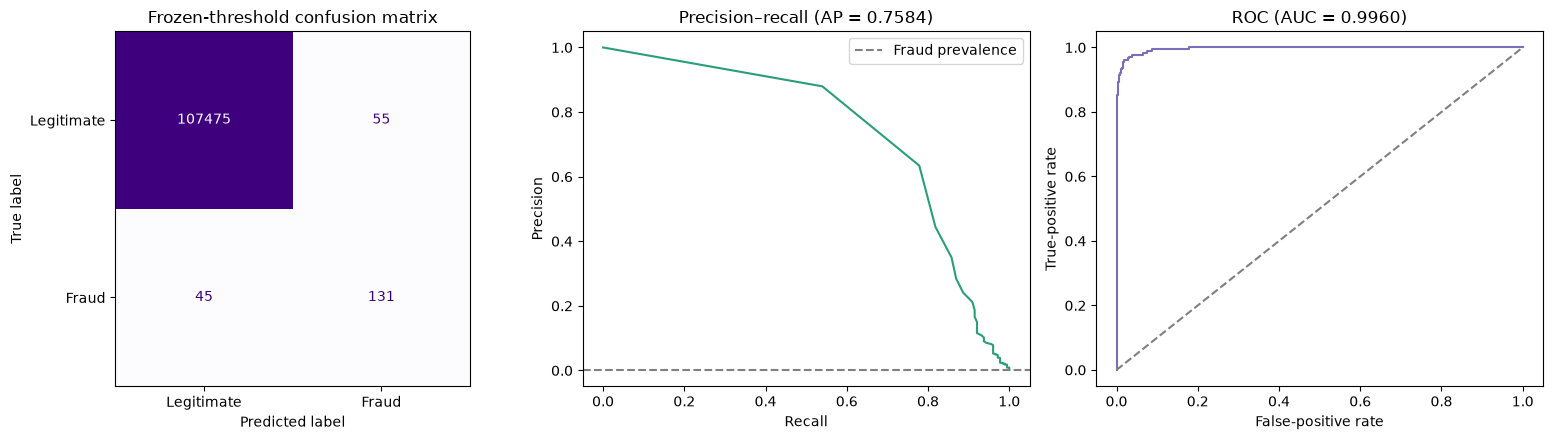

Correct ordinary payments: 107,475; false alarms: 55; missed fraud: 45; detected fraud: 131.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(np.asarray(reproduced["confusion_matrix"]), display_labels=["Legitimate", "Fraud"]).plot(
    ax=axes[0], colorbar=False, cmap="Purples", values_format="d")
axes[0].set_title("Frozen-threshold confusion matrix")
pr = reproduced["pr_curve"]
axes[1].plot(pr["x"], pr["y"], color="#299e79")
axes[1].axhline(test.label.mean(), linestyle="--", color="gray", label="Fraud prevalence")
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision–recall (AP = {reproduced['average_precision']:.4f})")
axes[1].legend()
roc = reproduced["roc_curve"]
axes[2].plot(roc["x"], roc["y"], color="#7b6db7")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set(xlabel="False-positive rate", ylabel="True-positive rate", title=f"ROC (AUC = {reproduced['roc_auc']:.4f})")
fig.tight_layout()
plt.show()
TN, FP, FN, TP = np.asarray(reproduced["confusion_matrix"]).ravel()
print(f"Correct ordinary payments: {TN:,}; false alarms: {FP:,}; missed fraud: {FN:,}; detected fraud: {TP:,}.")

## 7. Controlled experiment: does earlier history help?

These are two instances of the selected estimator using the same fitted rows and settings. Their feature sets differ: current-payment features alone versus those features plus history. Each threshold is selected on validation. Do not assume that history improves every metric; interpret the recorded outcomes.

In [9]:
history_comparison = metadata["history_comparison"]
display(pd.DataFrame([
    {"Feature set": "Current payment only", **{key: history_comparison["current_payment_only"][key]
        for key in ("precision", "recall", "f1", "average_precision", "roc_auc", "threshold")}},
    {"Feature set": "Current payment + earlier history", **{key: history_comparison["with_history"][key]
        for key in ("precision", "recall", "f1", "average_precision", "roc_auc", "threshold")}},
]))
print(history_comparison["method"])
print("F1 difference (history minus current-payment only):",
      history_comparison["with_history"]["f1"] - history_comparison["current_payment_only"]["f1"])

,Feature set,precision,recall,f1,average_precision,roc_auc,threshold
0,Current payment only,0.690909,0.647727,0.668622,0.712686,0.996575,0.993489
1,Current payment + earlier history,0.704301,0.744318,0.723757,0.758371,0.996005,0.965891


Same Gradient Boosting settings and fitted rows; each threshold selected on validation. Historical features are the only feature-set difference.
F1 difference (history minus current-payment only): 0.05513520519758275


## 8. Explain an actual held-out decision and verify export parity

The exported demo includes correct decisions and any available mistakes. Its raw account histories recreate training-time features exactly. For Decision Trees/Random Forests, contributions add fraud-score changes along actual decision paths. Histogram Gradient Boosting uses count-weighted descendant-leaf references and adds path contributions in log-odds. Logistic Regression adds feature coefficient terms in log-odds. These are estimator explanations, not SHAP values or causal effects.

Historical observations and model contributions are distinct: an unusually large amount is an observation; only the fitted estimator determines its contribution.

All 16 actual demo cases retain raw-history/model-export prediction parity.
{'account': 'CARD-0101', 'amount_USD': np.float64(20.44), 'actual_label': 0, 'model_score': 0.9948163132681904, 'threshold': 0.9658906106277161, 'flag_for_review': True}


,Feature,Contribution
7,Payments in the previous 24 hours,-0.691204
9,Merchant used before,-0.187201
8,Minutes since the previous payment,-0.102136
10,Category used before,0.000000
11,Earlier history available,0.000480
6,Payments in the previous hour,0.005039
3,Day of week,0.043444
5,Amount / earlier average,0.149118
1,Time of day (sine),0.228798
2,Time of day (cosine),0.460297


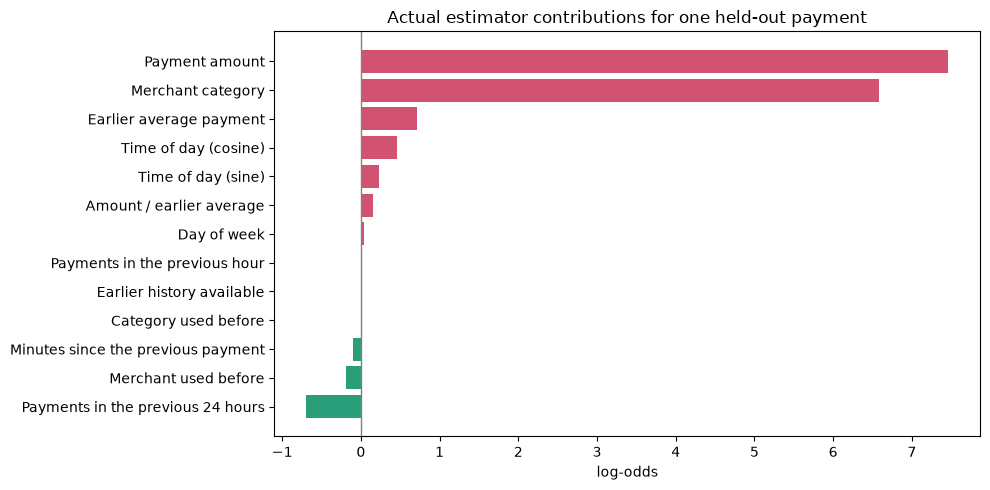

In [10]:
demo = pd.read_csv(ARTIFACTS / "demo_cases.csv", float_precision="round_trip")
history = pd.read_csv(ARTIFACTS / "account_history.csv", float_precision="round_trip")
for _, case in demo.iterrows():
    rebuilt = payment_features(history, case[list(RAW_COLUMNS)].to_dict())
    score, flagged = score_payment(rebuilt, bundle)
    np.testing.assert_allclose(score, case.model_score, atol=1e-12, rtol=0)
    assert flagged == bool(case.flagged)
print(f"All {len(demo)} actual demo cases retain raw-history/model-export prediction parity.")
case = demo.iloc[0]
featured = payment_features(history, case[list(RAW_COLUMNS)].to_dict())
score, flagged = score_payment(featured, bundle)
explanation = explain_payment(featured, bundle)
np.testing.assert_allclose(explanation["baseline"] + sum(explanation["contributions"].values()),
                           explanation["output"], atol=1e-9, rtol=0)
print({"account": case.account_id, "amount_USD": case.amount, "actual_label": int(case.label),
       "model_score": score, "threshold": bundle.threshold, "flag_for_review": flagged})
contribution_table = pd.DataFrame([
    {"Feature": FEATURE_LABELS.get(name, name), "Contribution": value}
    for name, value in explanation["contributions"].items()
]).sort_values("Contribution")
display(contribution_table)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(contribution_table.Feature, contribution_table.Contribution,
        color=np.where(contribution_table.Contribution >= 0, "#d25271", "#299e79"))
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Actual estimator contributions for one held-out payment")
ax.set_xlabel(explanation["unit"])
fig.tight_layout()
plt.show()

## 9. Hypothetical payment: inference without a known label

Editing a payment gives a new scenario with no ground truth. The model can score it, but the modified row cannot enter the accuracy report. The application follows this same distinction.

In [11]:
hypothetical = case[list(RAW_COLUMNS)].to_dict()
hypothetical["transaction_id"] = "NOTEBOOK-WHAT-IF"
hypothetical["amount"] = max(1.0, float(case.amount) * 1.5)
what_if_features = payment_features(history, hypothetical)
what_if_score, what_if_flag = score_payment(what_if_features, bundle)
print({"scenario": "Hypothetical payment — no known fraud label", "amount_USD": hypothetical["amount"],
       "model_score": what_if_score, "flag_for_review": what_if_flag})

{'scenario': 'Hypothetical payment — no known fraud label', 'amount_USD': 30.660000000000004, 'model_score': 8.51333338233651e-06, 'flag_for_review': False}


## 10. Conclusions and limitations

Use the achieved comparison and confusion matrix above when presenting this study. Explain both false alarms and missed fraud. The selected threshold optimizes validation F1 for this experiment; it is not a real bank's cost policy.

- The data is public **synthetic** credit-card activity, and the dashboard uses sample accounts.
- The study uses the verified published portion, not the complete original collection.
- The chronological evaluation can include the same accounts across periods; unseen-account and cold-start performance need separate studies.
- Initial aggregate test results were inspected during development; independent external evaluation remains future work.
- Scores are **uncalibrated**. Class weights and training sampling alter the fitted prior; a displayed score is not a measured real-world probability.
- The model has no bank connection, device/authentication signals, verified customer location, scam conversation, or recipient intent.
- Explanations reproduce this estimator's calculation; they do not establish causation or guarantee payment safety.

See `docs/CARD_MODEL.md` for the full feature contract and `docs/PRESENTATION_GUIDE.md` for a viva outline. The original PCA notebook is preserved separately for academic traceability.